<a href="https://colab.research.google.com/github/reezyhudson865/AI_Projects/blob/main/RHudson_Tokenization_Regex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Regex + Tokenization — SMS Spam Detection
**Course:** AI 102: Natural Language-based Programming Techniques  
- **Name:** Reezy Hudson  
- **NetID:** rhudso10  



The following lab was completed in an undergrad Applied AI class at UT-Knoxville in the Spring 2026 semester. The lab follows regex and tokenization for SMS spam detection. The lab objective was outlined by the professor. All rights reserved.

In [ ]:
print("="*60)
print("Exercise 4.1: Extract Phone Numbers")
print("="*60)

#Complete regex pattern for phone numbers
phone_pattern = r'(\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}|\d{3}[\s.-]\d{4})'

def extract_phones(text):
    return re.findall(phone_pattern, text)

#Test on messages
found_any = False
match_count = 0
for idx, row in sms_df.iterrows():
    phones = extract_phones(row['message'])
    if phones:
        found_any = True
        print(f"\n[{row['label'].upper()}] {row['message'][:50]}...")
        print(f"  Phones: {phones}")
        match_count += 1
        if match_count >= 5: break

if not found_any:
    print("\n(No phone numbers found in messages)")

Exercise 4.1: Extract Phone Numbers

[SPAM] Free entry in 2 a wkly comp to win FA Cup final tk...
  Phones: ['0845281007']

[SPAM] WINNER!! As a valued network customer you have bee...
  Phones: ['0906170146']

[SPAM] Had your mobile 11 months or more? U R entitled to...
  Phones: ['0800298603']

[SPAM] 07732584351 - Rodger Burns - MSG = We tried to cal...
  Phones: ['0773258435', '0800093070']

[SPAM] Congrats! 1 year special cinema pass for 2 is your...
  Phones: ['0906120946']


### Exercise 4.2: Extract URLs (8 pts)

In [ ]:
print("\n" + "="*60)
print("Exercise 4.2: Extract URLs")
print("="*60)

#Complete regex pattern for URL
url_pattern = r'(https?://[^\s]+|www\.[^\s]+)'

def extract_urls(text):
    return re.findall(url_pattern, text)

#Test on messages
found_any = False
match_count = 0
for idx, row in sms_df.iterrows():
    urls = extract_urls(row['message'])
    if urls:
        found_any = True
        print(f"\n[{row['label'].upper()}] {row['message'][:50]}...")
        print(f"  URLs: {urls}")
        match_count += 1
        if match_count >= 5: break

if not found_any:
    print("\n(No URLs found in messages)")


Exercise 4.2: Extract URLs

[SPAM] URGENT! You have won a 1 week FREE membership in o...
  URLs: ['www.dbuk.net']

[SPAM] XXXMobileMovieClub: To use your credit, click the ...
  URLs: ['http://wap.']

[SPAM] -PLS STOP bootydelious (32/F) is inviting you to b...
  URLs: ['www.SMS.ac/u/bootydelious']

[SPAM] Are you unique enough? Find out from 30th August. ...
  URLs: ['www.areyouunique.co.uk']

[SPAM] 500 New Mobiles from 2004, MUST GO! Txt: NOKIA to ...
  URLs: ['www.4-tc.biz']


In [ ]:
print("\n" + "="*60)
print("Exercise 4.3: Find Spam Keywords")
print("="*60)

#Count spam indicator keywords
spam_keywords = ['free', 'call', 'claim', 'winner', 'urgent', 'limited']

def count_spam_keywords(text):
    count = 0
    found = []
    for keyword in spam_keywords:
        #Find keyword matches
        matches = re.findall(rf'\b{keyword}\b', text, flags=re.I)
        if matches:
            count += len(matches)
            found.append((keyword, len(matches)))
    return count, found

#Test on messages
print("Analysis of first 5 matches:")
match_count = 0
for idx, row in sms_df.iterrows():
    count, keywords = count_spam_keywords(row['message'])
    if count > 0:
        #Print informative output for students
        print(f"\n--- Match #{match_count + 1} ---")
        print(f"Message: \"{row['message'][:60]}...\"")
        print(f"Label: {row['label']}")
        print(f"Found {count} keywords: {keywords}")

        match_count += 1
        if match_count >= 5:
            print("\n...Stopping loop after 5 matches to keep output concise.")
            break


Exercise 4.3: Find Spam Keywords
Analysis of first 5 matches:

--- Match #1 ---
Message: "Free entry in 2 a wkly comp to win FA Cup final tkts 21st Ma..."
Label: spam
Found 1 keywords: [('free', 1)]

--- Match #2 ---
Message: "WINNER!! As a valued network customer you have been selected..."
Label: spam
Found 4 keywords: [('call', 1), ('claim', 2), ('winner', 1)]

--- Match #3 ---
Message: "Had your mobile 11 months or more? U R entitled to Update to..."
Label: spam
Found 3 keywords: [('free', 2), ('call', 1)]

--- Match #4 ---
Message: "URGENT! You have won a 1 week FREE membership in our £100,00..."
Label: spam
Found 3 keywords: [('free', 1), ('claim', 1), ('urgent', 1)]

--- Match #5 ---
Message: "07732584351 - Rodger Burns - MSG = We tried to call you re y..."
Label: spam
Found 4 keywords: [('free', 2), ('call', 2)]

...Stopping loop after 5 matches to keep output concise.


In [ ]:
print("="*60)
print("Exercise 6.1: Analyze Spam vs Ham")
print("="*60)

#Collect words from spam and ham messages

spam_words = []
ham_words = []

for idx, row in sms_df.iterrows():
    result = tokenize_message(row['message'])
    if row['label'] == 'spam':
        #Add words to spam_words

        spam_words.extend(result['words'])
    else:
        #Add this message's words to ham_words
        ham_words.extend(result['words'])

print(f"\nTotal words in SPAM: {len(spam_words)}")
print(f"Total words in HAM: {len(ham_words)}")
print(f"\nSpam sample: {spam_words[:20]}")
print(f"\nHam sample: {ham_words[:20]}")

Exercise 6.1: Analyze Spam vs Ham

Total words in SPAM: 9446
Total words in HAM: 37788

Spam sample: ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'may', 'text', 'fa', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 'c', 'apply']

Ham sample: ['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat', 'ok', 'lar', 'joking', 'wif']


In [ ]:
print("\n" + "="*60)
print("Exercise 6.2: Word Frequency Analysis")
print("="*60)

#Count word frequencies

spam_freq = Counter([w for w in spam_words if len(w) > 2 and w.isalpha()])



#Count word frequencies
ham_freq = Counter([w for w in ham_words if len(w) > 2 and w.isalpha()])

print(f"\nTop 5 SPAM words:")
for word, count in spam_freq.most_common(5):
    print(f"  '{word}': {count}")

print(f"\nTop 5 HAM words:")
for word, count in ham_freq.most_common(5):
    print(f"  '{word}': {count}")


Exercise 6.2: Word Frequency Analysis

Top 5 SPAM words:
  'call': 346
  'free': 219
  'txt': 156
  'mobile': 123
  'text': 121

Top 5 HAM words:
  'get': 302
  'got': 245
  'know': 237
  'like': 233
  'call': 232


---
## **Part 7: Visualization**

Create a side-by-side bar chart comparing the top 10 words in spam vs. ham.

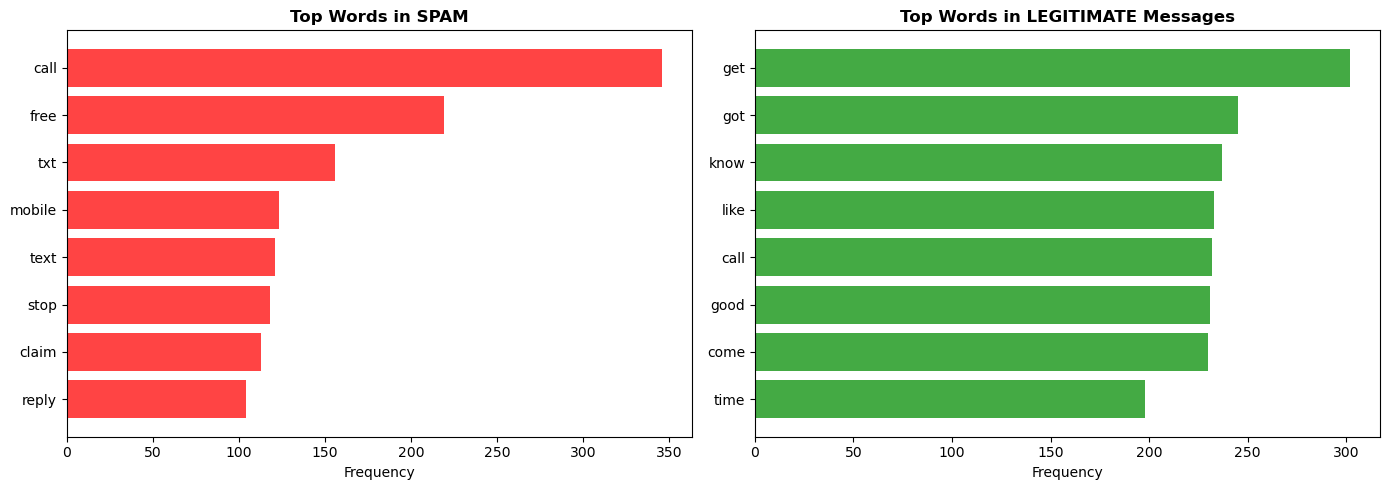

Visualization complete!


In [ ]:
#Create comparison chart
spam_top = spam_freq.most_common(8)
ham_top = ham_freq.most_common(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Extract words and counts, then create bar charts
spam_words_list = [w for w, c in spam_top]
spam_counts = [c for w, c in spam_top]
ax1.barh(spam_words_list, spam_counts, color='#ff4444')
ax1.set_xlabel('Frequency')
ax1.set_title('Top Words in SPAM', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

#For ham:
ham_words_list = [w for w, c in ham_top]
ham_counts = [c for w, c in ham_top]
ax2.barh(ham_words_list, ham_counts, color='#44aa44')
ax2.set_xlabel('Frequency')
ax2.set_title('Top Words in LEGITIMATE Messages', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("Visualization complete!")